In [3]:
#cargamos el dataset de train_transaction y train_identity
import pandas as pd

train_transaction = pd.read_csv("../data/raw/train_transaction.csv")
train_identity = pd.read_csv("../data/raw/train_identity.csv")

In [4]:
#miramos en crudo
print("train_transaction shape:", train_transaction.shape)
print("train_identity shape:", train_identity.shape)

train_transaction shape: (590540, 394)
train_identity shape: (144233, 41)


In [5]:
#Vemos la informacion de el set y analizamos la coorelacion de valores nulos
train_identity.info()

<class 'pandas.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  str    
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  str    
 16  id_16          129340 non-null  str    
 17  id_17          139369 non-null  float64


In [6]:
#Repetimos el analissis para el dataset de train_transaction
train_transaction.info()
train_transaction.dtypes.value_counts()
train_transaction.isnull().mean().sort_values(ascending=False).head(20)

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V149     0.861237
V141     0.861237
V146     0.861237
V154     0.861237
V162     0.861237
V142     0.861237
V158     0.861237
V161     0.861237
V157     0.861237
V138     0.861237
V139     0.861237
dtype: float64

In [7]:
#Verificacmos coorelacion de las columnas nulas que coinciden en porcentaje de nulos 
missing_cols = ['V138', 'V139', 'V141', 'V142', 'V146', 'V149', 'V153', 'V154', 'V157', 'V158', 'V161', 'V162']

train_transaction[missing_cols].isnull().corr()

,V138,V139,V141,V142,V146,V149,V153,V154,V157,V158,V161,V162
V138,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
V139,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
V141,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
V142,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
V146,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
V149,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
V153,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
V154,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
V157,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
V158,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [8]:
#Volvemos a verificar pero ahora 1 a 1 para confirmar 
(train_transaction['V138'].isnull() == train_transaction['V139'].isnull()).mean()

np.float64(1.0)

In [9]:
#Visualizamos los valores de la columna 'is fraud' para ver la distribucion, siendo esta la mas importante para nuestro analisis
train_transaction['isFraud'].value_counts()
train_transaction['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [10]:
train_transaction.select_dtypes(include='str').columns.tolist()

['ProductCD',
 'card4',
 'card6',
 'P_emaildomain',
 'R_emaildomain',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9']

In [11]:
#Verificamos si las columnas M1 a M9 son de tipo Match, que haria que los valores fueran T/F
for col in ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']:
    print(col, ":", train_transaction[col].unique())

M1 : <ArrowStringArray>
['T', nan, 'F']
Length: 3, dtype: str
M2 : <ArrowStringArray>
['T', nan, 'F']
Length: 3, dtype: str
M3 : <ArrowStringArray>
['T', nan, 'F']
Length: 3, dtype: str
M4 : <ArrowStringArray>
['M2', 'M0', nan, 'M1']
Length: 4, dtype: str
M5 : <ArrowStringArray>
['F', 'T', nan]
Length: 3, dtype: str
M6 : <ArrowStringArray>
['T', 'F', nan]
Length: 3, dtype: str
M7 : <ArrowStringArray>
[nan, 'F', 'T']
Length: 3, dtype: str
M8 : <ArrowStringArray>
[nan, 'F', 'T']
Length: 3, dtype: str
M9 : <ArrowStringArray>
[nan, 'F', 'T']
Length: 3, dtype: str


In [12]:
#Ahora visualizamos las columnas de str principales y vemos la cantidad de valores unicos que tienen, para ver si es viable hacer un one hot encoding o no
for col in ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']:
    print(col, ":", train_transaction[col].nunique(), "valores únicos")

ProductCD : 5 valores únicos
card4 : 4 valores únicos
card6 : 4 valores únicos
P_emaildomain : 59 valores únicos
R_emaildomain : 60 valores únicos


In [13]:
#Primero unimos los valores de las dos tablas rellenando con nulos las transacciones sin identidad 
df = train_transaction.merge(train_identity, on='TransactionID', how='left')

In [14]:
#Vemos el resultado de la union de los dos datasets
print(df.shape)

(590540, 434)


In [15]:
df.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


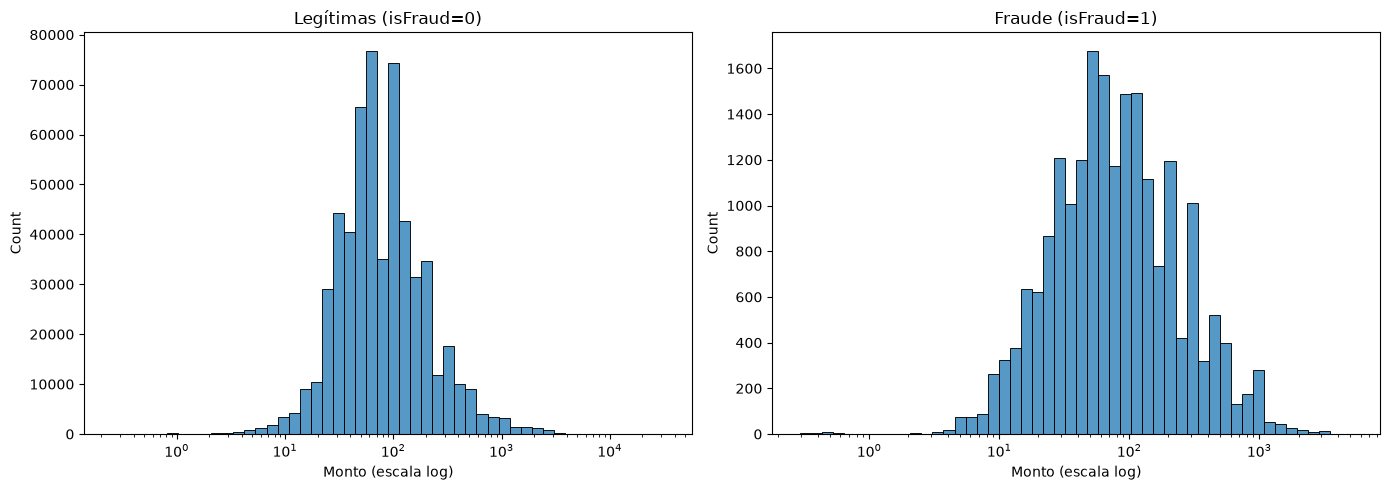

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2,  figsize=(14, 5), sharey=False)

sns.histplot(df[df['isFraud'] == 0]['TransactionAmt'], bins=50, ax=axes[0], log_scale=True)
axes[0].set_title('Legítimas (isFraud=0)')
axes[0].set_xlabel('Monto (escala log)')

sns.histplot(df[df['isFraud'] == 1]['TransactionAmt'], bins=50, ax=axes[1], log_scale=True)
axes[1].set_title('Fraude (isFraud=1)')
axes[1].set_xlabel('Monto (escala log)')

plt.tight_layout()
plt.show()

In [17]:
df.groupby('isFraud')['TransactionDT'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,7.360791e+06,4.623930e+06,86400.0,3010651.0,7271678.0,11253338.0,15811131.0
1,20663.0,7.690033e+06,4.416551e+06,89760.0,3965858.0,7575230.0,11217428.0,15810876.0


/tmp/ipykernel_14744/2377603085.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour_of_day'] = (df['TransactionDT'] // 3600) % 24


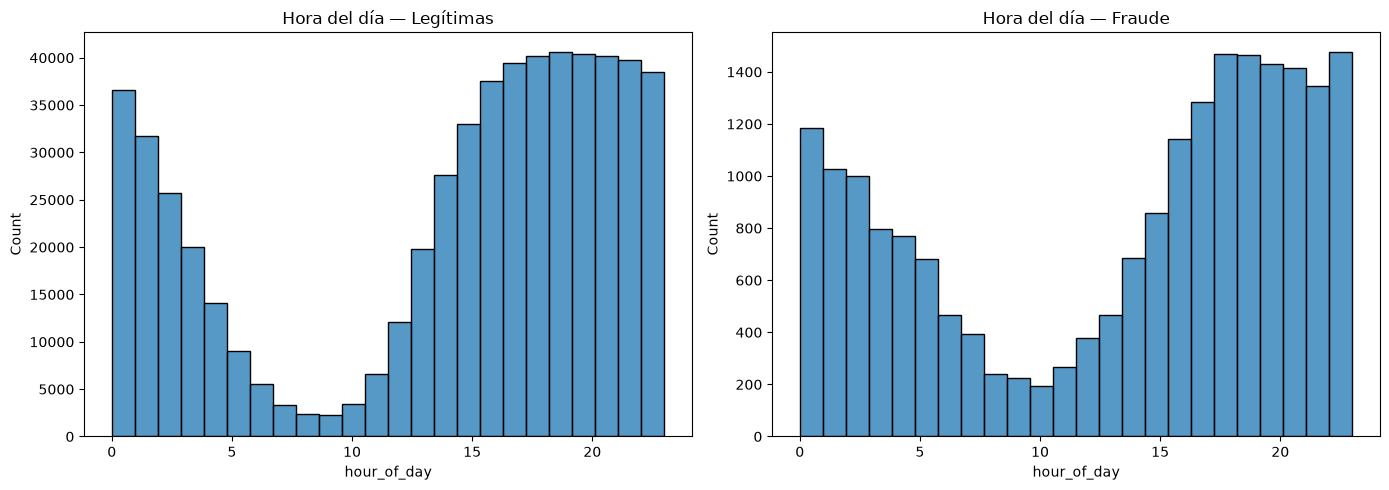

In [18]:
df['hour_of_day'] = (df['TransactionDT'] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df['isFraud'] == 0]['hour_of_day'], bins=24, ax=axes[0])
axes[0].set_title('Hora del día — Legítimas')

sns.histplot(df[df['isFraud'] == 1]['hour_of_day'], bins=24, ax=axes[1])
axes[1].set_title('Hora del día — Fraude')

plt.tight_layout()
plt.show()

In [19]:
df.groupby('ProductCD')['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
ProductCD,,
C,0.116873,68519
S,0.058996,11628
H,0.047662,33024
R,0.037826,37699
W,0.020399,439670


In [20]:
df.groupby('card4')['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
card4,,
discover,0.077282,6651
visa,0.034756,384767
mastercard,0.034331,189217
american express,0.028698,8328


In [21]:
df.groupby('card6')['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
card6,,
credit,0.066785,148986
debit,0.024263,439938
charge card,0.000000,15
debit or credit,0.000000,30


In [22]:
v_cols = [col for col in df.columns if col.startswith('V')]
print(len(v_cols))

339


In [23]:
v_missing_pct = df[v_cols].isnull().mean()
grupos = v_missing_pct.groupby(v_missing_pct).apply(lambda x: list(x.index))

In [24]:
for pct, cols in grupos.items():
    if len(cols) > 1:
        print(f"{pct:.4f} → {len(cols)} columnas: {cols}")

0.0000 → 32 columnas: ['V279', 'V280', 'V284', 'V285', 'V286', 'V287', 'V290', 'V291', 'V292', 'V293', 'V294', 'V295', 'V297', 'V298', 'V299', 'V302', 'V303', 'V304', 'V305', 'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V316', 'V317', 'V318', 'V319', 'V320', 'V321']
0.0005 → 43 columnas: ['V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V126', 'V127', 'V128', 'V129', 'V130', 'V131', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137']
0.0021 → 11 columnas: ['V281', 'V282', 'V283', 'V288', 'V289', 'V296', 'V300', 'V301', 'V313', 'V314', 'V315']
0.1288 → 23 columnas: ['V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34']
0.1306 → 22 columnas: ['V53', 'V54', 'V55', 'V56', 'V57', 'V58',

In [25]:
for pct, cols in grupos.items():
    if len(cols) > 1:
        corr_matrix = df[cols].isnull().corr()
        min_corr = corr_matrix.values.min()
        print(f"Grupo con {len(cols)} columnas — correlación mínima: {min_corr:.4f}")

Grupo con 32 columnas — correlación mínima: 1.0000
Grupo con 43 columnas — correlación mínima: 1.0000
Grupo con 11 columnas — correlación mínima: 1.0000
Grupo con 23 columnas — correlación mínima: 1.0000
Grupo con 22 columnas — correlación mínima: 1.0000
Grupo con 20 columnas — correlación mínima: 1.0000
Grupo con 18 columnas — correlación mínima: 1.0000
Grupo con 11 columnas — correlación mínima: 1.0000
Grupo con 16 columnas — correlación mínima: 1.0000
Grupo con 19 columnas — correlación mínima: 1.0000
Grupo con 31 columnas — correlación mínima: 1.0000
Grupo con 46 columnas — correlación mínima: 1.0000
Grupo con 18 columnas — correlación mínima: 1.0000
Grupo con 11 columnas — correlación mínima: 1.0000
Grupo con 18 columnas — correlación mínima: 1.0000


In [26]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlaciones = df[numeric_cols].corrwith(df['isFraud']).sort_values(ascending=False)
print(correlaciones.head(15))
print(correlaciones.tail(15))

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
dtype: float64
V35     -0.077116
D15     -0.077519
D2      -0.083583
id_07   -0.084768
V70     -0.100900
V30     -0.103088
V69     -0.104521
V91     -0.105453
V29     -0.107852
V90     -0.110168
V49     -0.110920
V48     -0.115786
id_01   -0.120099
D7      -0.127199
D8      -0.142636
dtype: float64


In [27]:
bloque_alto = ['V217', 'V218', 'V219', 'V223', 'V224', 'V225', 'V226', 'V228', 'V229', 'V230',
               'V231', 'V232', 'V233', 'V235', 'V236', 'V237', 'V240', 'V241', 'V242', 'V243',
               'V244', 'V246', 'V247', 'V248', 'V249', 'V252', 'V253', 'V254', 'V257', 'V258',
               'V260', 'V261', 'V262', 'V263', 'V264', 'V265', 'V266', 'V267', 'V268', 'V269',
               'V273', 'V274', 'V275', 'V276', 'V277', 'V278']

df[bloque_alto].corrwith(df['isFraud']).sort_values(ascending=False)

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V258    0.297151
V228    0.268861
V230    0.231740
V243    0.210238
V247    0.179711
V252    0.153364
V262    0.150338
V229    0.137225
V260    0.124889
V249    0.113887
V261    0.104785
V248    0.078518
V235    0.076194
V232    0.054602
V254    0.049901
V218    0.047565
V233    0.046226
V219    0.046042
V217    0.045785
V237    0.042722
V231    0.041289
V236    0.039979
V253    0.019652
V275    0.017120
V273    0.015676
V274    0.015518
V263    0.014730
V265    0.014224
V277    0.010738
V278    0.010040
V276    0.009681
V264    0.009358
V225    0.007936
V240    0.002793
V226    0.002273
V241    0.001988
V224    0.001151
V223    0.001107
V268   -0.005161
V266   -0.005257
V269   -0.005904
V267   -0.007390
dtype: float64

In [28]:
df_sorted = df.sort_values('TransactionDT').reset_index(drop=True)

split_point = int(len(df_sorted) * 0.8)

train = df_sorted.iloc[:split_point]
test = df_sorted.iloc[split_point:]

print("Train:", train.shape, "| rango de tiempo:", train['TransactionDT'].min(), "-", train['TransactionDT'].max())
print("Test:", test.shape, "| rango de tiempo:", test['TransactionDT'].min(), "-", test['TransactionDT'].max())

Train: (472432, 435) | rango de tiempo: 86400 - 12192842
Test: (118108, 435) | rango de tiempo: 12192900 - 15811131


In [29]:
print("Tasa de fraude en train:", train['isFraud'].mean())
print("Tasa de fraude en test:", test['isFraud'].mean())

Tasa de fraude en train: 0.03513521522674162
Tasa de fraude en test: 0.034409184813899145


In [30]:
features = ['TransactionAmt', 'ProductCD', 'card4', 'card6', 'hour_of_day']

X_train = train[features].copy()
X_test = test[features].copy()

y_train = train['isFraud'].copy()
y_test = test['isFraud'].copy()

X_train = pd.get_dummies(X_train, columns=['ProductCD', 'card4', 'card6'])
X_test = pd.get_dummies(X_test, columns=['ProductCD', 'card4', 'card6'])

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(X_train.shape, X_test.shape)

(472432, 15) (118108, 15)


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [32]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_pred_proba))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))

Precision: 0.0
Recall: 0.0
F1: 0.0
PR-AUC: 0.11338683024021438

Matriz de confusión:
 [[114044      0]
 [  4064      0]]


/home/sgc081372/proyectos/fraudshield-ai/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [34]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = f1_scores[:-1].argmax()

print("Mejor umbral (F1 máximo):", thresholds[best_idx])
print("F1 en ese punto:", f1_scores[best_idx])

Mejor umbral (F1 máximo): 0.12171752940630098
F1 en ese punto: 0.20373894543344645


In [35]:
best_threshold = 0.124

y_pred_final = (y_pred_proba >= best_threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_final, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_final, zero_division=0))
print("F1:", f1_score(y_test, y_pred_final, zero_division=0))

Precision: 0.18645121193287756
Recall: 0.22145669291338582
F1: 0.20245191766955348


In [36]:
grupos_v = {
    'v_grp1': ['V279', 'V280', 'V284', 'V285', 'V286', 'V287', 'V290', 'V291', 'V292', 'V293', 'V294', 'V295', 'V297', 'V298', 'V299', 'V302', 'V303', 'V304', 'V305', 'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V316', 'V317', 'V318', 'V319', 'V320', 'V321'],
    'v_grp2': ['V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V126', 'V127', 'V128', 'V129', 'V130', 'V131', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137'],
    'v_grp3': ['V281', 'V282', 'V283', 'V288', 'V289', 'V296', 'V300', 'V301', 'V313', 'V314', 'V315'],
    'v_grp4': ['V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34'],
    'v_grp5': ['V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74'],
    'v_grp6': ['V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94'],
    'v_grp7': ['V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52'],
    'v_grp8': ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11'],
    'v_grp9': ['V220', 'V221', 'V222', 'V227', 'V234', 'V238', 'V239', 'V245', 'V250', 'V251', 'V255', 'V256', 'V259', 'V270', 'V271', 'V272'],
    'v_grp10': ['V169', 'V170', 'V171', 'V174', 'V175', 'V180', 'V184', 'V185', 'V188', 'V189', 'V194', 'V195', 'V197', 'V198', 'V200', 'V201', 'V208', 'V209', 'V210'],
    'v_grp11': ['V167', 'V168', 'V172', 'V173', 'V176', 'V177', 'V178', 'V179', 'V181', 'V182', 'V183', 'V186', 'V187', 'V190', 'V191', 'V192', 'V193', 'V196', 'V199', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207', 'V211', 'V212', 'V213', 'V214', 'V215', 'V216'],
    'v_grp12': ['V217', 'V218', 'V219', 'V223', 'V224', 'V225', 'V226', 'V228', 'V229', 'V230', 'V231', 'V232', 'V233', 'V235', 'V236', 'V237', 'V240', 'V241', 'V242', 'V243', 'V244', 'V246', 'V247', 'V248', 'V249', 'V252', 'V253', 'V254', 'V257', 'V258', 'V260', 'V261', 'V262', 'V263', 'V264', 'V265', 'V266', 'V267', 'V268', 'V269', 'V273', 'V274', 'V275', 'V276', 'V277', 'V278'],
    'v_grp13': ['V322', 'V323', 'V324', 'V325', 'V326', 'V327', 'V328', 'V329', 'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338', 'V339'],
    'v_grp14': ['V143', 'V144', 'V145', 'V150', 'V151', 'V152', 'V159', 'V160', 'V164', 'V165', 'V166'],
    'v_grp15': ['V138', 'V139', 'V140', 'V141', 'V142', 'V146', 'V147', 'V148', 'V149', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V161', 'V162', 'V163'],
}

for grp_name, cols in grupos_v.items():
    df[f'{grp_name}_is_missing'] = df[cols[0]].isnull().astype(int)

/tmp/ipykernel_14744/382056512.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{grp_name}_is_missing'] = df[cols[0]].isnull().astype(int)
/tmp/ipykernel_14744/382056512.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{grp_name}_is_missing'] = df[cols[0]].isnull().astype(int)
/tmp/ipykernel_14744/382056512.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

In [37]:
missing_cols = [f'{grp}_is_missing' for grp in grupos_v.keys()]
print(df[missing_cols].sum())

v_grp1_is_missing         12
v_grp2_is_missing        314
v_grp3_is_missing       1269
v_grp4_is_missing      76073
v_grp5_is_missing      77096
v_grp6_is_missing      89164
v_grp7_is_missing     168969
v_grp8_is_missing     279287
v_grp9_is_missing     449124
v_grp10_is_missing    450721
v_grp11_is_missing    450909
v_grp12_is_missing    460110
v_grp13_is_missing    508189
v_grp14_is_missing    508589
v_grp15_is_missing    508595
dtype: int64


In [38]:
v_cols = [col for col in df.columns if col.startswith('V') and 'is_missing' not in col]

medianas_v = train[v_cols].median()

train[v_cols] = train[v_cols].fillna(medianas_v)
test[v_cols] = test[v_cols].fillna(medianas_v)

print(train[v_cols].isnull().sum().sum())
print(test[v_cols].isnull().sum().sum())

0
0


In [39]:
print(train['P_emaildomain'].value_counts().head(15))

P_emaildomain
gmail.com        182692
yahoo.com         80854
hotmail.com       37158
anonymous.com     29961
aol.com           22618
comcast.net        6496
icloud.com         5031
outlook.com        4080
msn.com            3340
att.net            3133
live.com           2475
sbcglobal.net      2395
verizon.net        2252
ymail.com          1914
bellsouth.net      1580
Name: count, dtype: int64


In [40]:
for n in [3, 4, 5, 6, 7, 8]:
    total_no_nulos = train['P_emaildomain'].notna().sum()
    suma_top = train['P_emaildomain'].value_counts().head(n).sum()
    print(f"top {n}: {suma_top / total_no_nulos:.1%}")

top 3: 75.4%
top 4: 82.9%
top 5: 88.6%
top 6: 90.2%
top 7: 91.5%
top 8: 92.5%


In [41]:
top_domains = train['P_emaildomain'].value_counts().head(5).index.tolist()

def agrupar_dominio(x):
    if pd.isna(x):
        return 'sin_dominio'
    elif x in top_domains:
        return x
    else:
        return 'otros'

train['P_emaildomain_grouped'] = train['P_emaildomain'].apply(agrupar_dominio)
test['P_emaildomain_grouped'] = test['P_emaildomain'].apply(agrupar_dominio)

print(train['P_emaildomain_grouped'].value_counts())

P_emaildomain_grouped
gmail.com        182692
yahoo.com         80854
sin_dominio       73586
otros             45563
hotmail.com       37158
anonymous.com     29961
aol.com           22618
Name: count, dtype: int64


/tmp/ipykernel_14744/3769671842.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['P_emaildomain_grouped'] = train['P_emaildomain'].apply(agrupar_dominio)
/tmp/ipykernel_14744/3769671842.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['P_emaildomain_grouped'] = test['P_emaildomain'].apply(agrupar_dominio)


In [42]:
print(train['R_emaildomain'].value_counts().head(15))

for n in [3, 4, 5, 6, 7, 8]:
    total_no_nulos = train['R_emaildomain'].notna().sum()
    suma_top = train['R_emaildomain'].value_counts().head(n).sum()
    print(f"top {n}: {suma_top / total_no_nulos:.1%}")

top_domains_r = train['R_emaildomain'].value_counts().head(5).index.tolist()

def agrupar_dominio_r(x):
    if pd.isna(x):
        return 'sin_dominio'
    elif x in top_domains_r:
        return x
    else:
        return 'otros'

train['R_emaildomain_grouped'] = train['R_emaildomain'].apply(agrupar_dominio_r)
test['R_emaildomain_grouped'] = test['R_emaildomain'].apply(agrupar_dominio_r)

print(train['R_emaildomain_grouped'].value_counts())

R_emaildomain
gmail.com        47290
hotmail.com      22984
anonymous.com    17271
yahoo.com         8879
aol.com           3254
outlook.com       2035
comcast.net       1578
yahoo.com.mx      1256
icloud.com        1138
msn.com            718
live.com           673
live.com.mx        622
verizon.net        552
sbcglobal.net      483
me.com             475
Name: count, dtype: int64
top 3: 77.1%
top 4: 84.9%
top 5: 87.7%
top 6: 89.5%
top 7: 90.9%
top 8: 92.0%
R_emaildomain_grouped
sin_dominio      358812
gmail.com         47290
hotmail.com       22984
anonymous.com     17271
otros             13942
yahoo.com          8879
aol.com            3254
Name: count, dtype: int64


/tmp/ipykernel_14744/3684222975.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['R_emaildomain_grouped'] = train['R_emaildomain'].apply(agrupar_dominio_r)
/tmp/ipykernel_14744/3684222975.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['R_emaildomain_grouped'] = test['R_emaildomain'].apply(agrupar_dominio_r)


In [43]:
registro_funciones = {}

def registrar(func):
    """Decorador que guarda la función en el diccionario registro_funciones"""
    registro_funciones[func.__name__] = func.__doc__ or "Sin descripción"
    return func

def ver_funciones_disponibles():
    for nombre, descripcion in registro_funciones.items():
        print(f"{nombre}: {descripcion}")

In [44]:
@registrar
def agrupar_por_top_optimo(train_col, test_col, umbral_ganancia_marginal=0.02, max_n=20, min_cobertura=0.5):
    """
    Encuentra el top N óptimo de una columna (basado en ganancia marginal)
    y aplica la agrupación 'top N + otros + sin_dato' a train y test.

    Si el top N necesario para alcanzar min_cobertura supera max_n,
    se usa max_n como límite (para no generar demasiadas columnas
    en distribuciones muy uniformes).
    """
    total_no_nulos = train_col.notna().sum()
    conteos = train_col.value_counts()
    cobertura_acumulada = (conteos.cumsum() / total_no_nulos)

    ganancia_marginal = cobertura_acumulada.diff().fillna(cobertura_acumulada.iloc[0])

    n_optimo = max_n
    for i, ganancia in enumerate(ganancia_marginal.head(max_n), start=1):
        if ganancia < umbral_ganancia_marginal and cobertura_acumulada.iloc[i - 1] >= min_cobertura:
            n_optimo = i
            break

    top_categorias = conteos.head(n_optimo).index.tolist()
    cobertura_final = cobertura_acumulada.iloc[n_optimo - 1]

    def _agrupar(x):
        if pd.isna(x):
            return 'sin_dato'
        elif x in top_categorias:
            return x
        else:
            return 'otros'

    train_grouped = train_col.apply(_agrupar)
    test_grouped = test_col.apply(_agrupar)

    print(f"Top usado: {n_optimo} | Cobertura: {cobertura_final:.1%}")

    return train_grouped, test_grouped

In [45]:
id_str_cols = ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30',
               'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
               'DeviceType', 'DeviceInfo']

for col in id_str_cols:
    print(col, ":", train[col].nunique(), "valores únicos")

id_12 : 2 valores únicos
id_15 : 3 valores únicos
id_16 : 2 valores únicos
id_23 : 3 valores únicos
id_27 : 2 valores únicos
id_28 : 2 valores únicos
id_29 : 2 valores únicos
id_30 : 72 valores únicos
id_31 : 110 valores únicos
id_33 : 212 valores únicos
id_34 : 4 valores únicos
id_35 : 2 valores únicos
id_36 : 2 valores únicos
id_37 : 2 valores únicos
id_38 : 2 valores únicos
DeviceType : 2 valores únicos
DeviceInfo : 1639 valores únicos


In [46]:
train['DeviceInfo_grouped'], test['DeviceInfo_grouped'] = agrupar_por_top_optimo(train['DeviceInfo'], test['DeviceInfo'])
train['id_30_grouped'], test['id_30_grouped'] = agrupar_por_top_optimo(train['id_30'], test['id_30'])
train['id_31_grouped'], test['id_31_grouped'] = agrupar_por_top_optimo(train['id_31'], test['id_31'])
train['id_33_grouped'], test['id_33_grouped'] = agrupar_por_top_optimo(train['id_33'], test['id_33'])

Top usado: 5 | Cobertura: 76.1%
Top usado: 13 | Cobertura: 78.0%


/tmp/ipykernel_14744/2002435902.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['DeviceInfo_grouped'], test['DeviceInfo_grouped'] = agrupar_por_top_optimo(train['DeviceInfo'], test['DeviceInfo'])
/tmp/ipykernel_14744/2002435902.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['id_30_grouped'], test['id_30_grouped'] = agrupar_por_top_optimo(train['id_30'], test['id_30'])


Top usado: 16 | Cobertura: 87.5%
Top usado: 15 | Cobertura: 86.3%


/tmp/ipykernel_14744/2002435902.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['id_31_grouped'], test['id_31_grouped'] = agrupar_por_top_optimo(train['id_31'], test['id_31'])
/tmp/ipykernel_14744/2002435902.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['id_33_grouped'], test['id_33_grouped'] = agrupar_por_top_optimo(train['id_33'], test['id_33'])


In [47]:
cols_baja_cardinalidad = ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29',
                          'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']

cols_agrupadas = ['P_emaildomain_grouped', 'R_emaildomain_grouped', 'DeviceInfo_grouped',
                   'id_30_grouped', 'id_31_grouped', 'id_33_grouped']

cols_negocio = ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

cols_para_encoding = cols_baja_cardinalidad + cols_agrupadas + cols_negocio

train_encoded = pd.get_dummies(train, columns=cols_para_encoding, dummy_na=True)
test_encoded = pd.get_dummies(test, columns=cols_para_encoding, dummy_na=True)

test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

cols_a_eliminar = ['P_emaildomain', 'R_emaildomain', 'DeviceInfo', 'id_30', 'id_31', 'id_33']
train_encoded = train_encoded.drop(columns=[c for c in cols_a_eliminar if c in train_encoded.columns])
test_encoded = test_encoded.drop(columns=[c for c in cols_a_eliminar if c in test_encoded.columns])

print(train_encoded.shape, test_encoded.shape)

(472432, 568) (118108, 568)


In [48]:
mediana_por_tarjeta = train.groupby('card1')['TransactionAmt'].median()

train['amt_relative_to_card'] = train['TransactionAmt'] / train['card1'].map(mediana_por_tarjeta)
test['amt_relative_to_card'] = test['TransactionAmt'] / test['card1'].map(mediana_por_tarjeta)

print(train['amt_relative_to_card'].isnull().sum())
print(test['amt_relative_to_card'].isnull().sum())

0
1293


/tmp/ipykernel_14744/1850852422.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['amt_relative_to_card'] = train['TransactionAmt'] / train['card1'].map(mediana_por_tarjeta)
/tmp/ipykernel_14744/1850852422.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['amt_relative_to_card'] = test['TransactionAmt'] / test['card1'].map(mediana_por_tarjeta)


In [49]:
train['amt_relative_to_card'] = train['amt_relative_to_card'].fillna(1.0)
test['amt_relative_to_card'] = test['amt_relative_to_card'].fillna(1.0)

print(train['amt_relative_to_card'].isnull().sum())
print(test['amt_relative_to_card'].isnull().sum())

0
0


In [50]:
# amt_relative_to_card se calculó sobre train/test; hay que copiarla a train_encoded/test_encoded
train_encoded['amt_relative_to_card'] = train['amt_relative_to_card']
test_encoded['amt_relative_to_card'] = test['amt_relative_to_card']
print(train_encoded.shape, test_encoded.shape)

(472432, 569) (118108, 569)


/tmp/ipykernel_14744/1023098410.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_encoded['amt_relative_to_card'] = train['amt_relative_to_card']
/tmp/ipykernel_14744/1023098410.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_encoded['amt_relative_to_card'] = test['amt_relative_to_card']


In [51]:
print(train_encoded.select_dtypes(include=['str', 'object']).columns.tolist())

[]


In [52]:
cols_excluir = ['isFraud', 'TransactionID', 'TransactionDT']

feature_cols = [col for col in train_encoded.columns if col not in cols_excluir]

X_train_full = train_encoded[feature_cols]
y_train_full = train_encoded['isFraud']

X_test_full = test_encoded[feature_cols]
y_test_full = test_encoded['isFraud']

print(X_train_full.shape, X_test_full.shape)

(472432, 566) (118108, 566)


In [53]:
from xgboost import XGBClassifier
import time

start = time.time()
xgb_model = XGBClassifier(random_state=42, eval_metric='aucpr')
xgb_model.fit(X_train_full, y_train_full)
tiempo_xgb = time.time() - start

xgb_pred_proba = xgb_model.predict_proba(X_test_full)[:, 1]
print(f"XGBoost entrenado en {tiempo_xgb:.2f}s")

XGBoost entrenado en 20.87s


In [54]:
import re

def limpiar_nombre_columna(col):
    return re.sub(r'[^A-Za-z0-9_]', '_', col)

X_train_lgbm = X_train_full.copy()
X_test_lgbm = X_test_full.copy()

X_train_lgbm.columns = [limpiar_nombre_columna(col) for col in X_train_lgbm.columns]
X_test_lgbm.columns = [limpiar_nombre_columna(col) for col in X_test_lgbm.columns]

print(X_train_lgbm.columns.duplicated().sum())
print(X_test_lgbm.columns.duplicated().sum())

0
0


In [55]:
from lightgbm import LGBMClassifier

start = time.time()
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_lgbm, y_train_full)
tiempo_lgbm = time.time() - start

lgbm_pred_proba = lgbm_model.predict_proba(X_test_lgbm)[:, 1]
print(f"LightGBM entrenado en {tiempo_lgbm:.2f}s")

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.376432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33896
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 553
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
LightGBM entrenado en 8.92s


In [56]:
from catboost import CatBoostClassifier

start = time.time()
cat_model = CatBoostClassifier(random_state=42, verbose=0)
cat_model.fit(X_train_lgbm, y_train_full)
tiempo_cat = time.time() - start

cat_pred_proba = cat_model.predict_proba(X_test_lgbm)[:, 1]
print(f"CatBoost entrenado en {tiempo_cat:.2f}s")

CatBoost entrenado en 108.29s


In [57]:
from sklearn.metrics import average_precision_score, precision_recall_curve

modelos_proba = {
    'XGBoost': xgb_pred_proba,
    'LightGBM': lgbm_pred_proba,
    'CatBoost': cat_pred_proba
}

tiempos = {'XGBoost': tiempo_xgb, 'LightGBM': tiempo_lgbm, 'CatBoost': tiempo_cat}

resultados = {}

for nombre, proba in modelos_proba.items():
    pr_auc = average_precision_score(y_test_full, proba)

    precisions, recalls, thresholds = precision_recall_curve(y_test_full, proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = f1_scores[:-1].argmax()

    resultados[nombre] = {
        'PR-AUC': pr_auc,
        'Mejor F1': f1_scores[best_idx],
        'Precision en mejor F1': precisions[best_idx],
        'Recall en mejor F1': recalls[best_idx],
        'Umbral óptimo': thresholds[best_idx],
        'Tiempo (s)': tiempos[nombre]
    }

resultados_df = pd.DataFrame(resultados).T
print(resultados_df)

            PR-AUC  Mejor F1  Precision en mejor F1  Recall en mejor F1  \
XGBoost   0.506433  0.506484               0.601761            0.437254   
LightGBM  0.514400  0.496054               0.580475            0.433071   
CatBoost  0.557873  0.541829               0.693400            0.444636   

          Umbral óptimo  Tiempo (s)  
XGBoost        0.269696   20.870247  
LightGBM       0.267069    8.915753  
CatBoost       0.298783  108.286469  


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

En este punto hubo un incidente de que se crasheo el sistema por haber corrido tres modelos distintos en paralelo, lo que hizo que se borrara completamente el notebook y debido al entorno que esta siendo utilizado, cuando se corrieron los multiples modelos se ocupo un exceso de memoria RAMM lo que provoco que el sistema de archivos remotos de WSL rompio la conexion y al cerrarse la pestana de VScode no se guardo el proceso y quedo vacio el notebook.

Se procedio a intentar recuperar el archivo por multiples metodos hasta que se consulto el historial de IPython (~/.ipython/profile_default/history.sqlite) consultado con sqlite3, esto identifico la sesion del kernel correspondiente y nos dio un archivo de testo con todo el notebook, luego se procedio a la reconstruccion de todo el notebook con este texto recuperando todo el notebook sin perdidas exitosamente.

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [58]:
#Ahora ya que elegimos para este caso el modelo de LightGBM queremos ajustar los hiperparametros para mejorar el rendimiento del modelo
#Para esto debemos primero dividir el dataset de train en train y validacion de manera (80/20) para poder evaluar el rendimiento del modelo con los hiperparametros ajustados
#Posteriormente podemos usar la validacion cruzada para evaluar el rendimiento del modelo con los hiperparametros ajustados


#Primero dividimos el dataset de train en dos partes de 80/20 de manera temporal siendo la validacion el 20% de los datos mas recientes
train_sorted = train.sort_values('TransactionDT').reset_index(drop=True)

split_point_val = int(len(train_sorted) * 0.8)

train_final = train_sorted.iloc[:split_point_val]
validation = train_sorted.iloc[split_point_val:]

print("Train final:", train_final.shape, "| rango:", train_final['TransactionDT'].min(), "-", train_final['TransactionDT'].max())
print("Validation:", validation.shape, "| rango:", validation['TransactionDT'].min(), "-", validation['TransactionDT'].max())

Train final: (377945, 442) | rango: 86400 - 9466264
Validation: (94487, 442) | rango: 9466279 - 12192842


In [59]:

#Ahora para poder evitar data leakage debemos aseguraernos de que se hagan los calculos nuevamente de las medianas y de los top N para cada uno de los sub sets de datos 
#Por lo que# debemos construir una funcion que nos permita hacer esto de manera automatica , esto lo dividiremos en dos partes para que una funcion se encargue de calcular las estadisticas y otra para transformar los datos de train

#Primeror construimos la funcion que nos permite calcular las estadisticas de manera automatica para cada uno de los sub sets de datos

@registrar
def encontrar_top_optimo_fit(serie, umbral_ganancia_marginal=0.02, max_n=20, min_cobertura=0.5):
    """
    FASE FIT: encuentra el top N óptimo de una columna (basado en ganancia marginal)
    y devuelve la lista de categorías top a usar, sin transformar nada.
    """
    total_no_nulos = serie.notna().sum()
    conteos = serie.value_counts()
    cobertura_acumulada = (conteos.cumsum() / total_no_nulos)

    ganancia_marginal = cobertura_acumulada.diff().fillna(cobertura_acumulada.iloc[0])

    n_optimo = max_n
    for i, ganancia in enumerate(ganancia_marginal.head(max_n), start=1):
        if ganancia < umbral_ganancia_marginal and cobertura_acumulada.iloc[i - 1] >= min_cobertura:
            n_optimo = i
            break

    top_categorias = conteos.head(n_optimo).index.tolist()
    cobertura_final = cobertura_acumulada.iloc[n_optimo - 1]

    print(f"Top usado: {n_optimo} | Cobertura: {cobertura_final:.1%}")

    return top_categorias


@registrar
def agrupar_transform(serie, top_categorias):
    """
    FASE TRANSFORM: aplica una lista de categorías top ya calculada
    para agrupar cualquier serie en 'top N + otros + sin_dato'.
    """
    def _agrupar(x):
        if pd.isna(x):
            return 'sin_dato'
        elif x in top_categorias:
            return x
        else:
            return 'otros'

    return serie.apply(_agrupar)

@registrar
def fit_feature_engineering(train_df, grupos_v):
    """
    Calcula todas las estadísticas de referencia necesarias para el
    Feature Engineering, usando ÚNICAMENTE el DataFrame de train recibido.
    Devuelve un diccionario con todo lo aprendido, sin transformar nada.
    """
    stats = {}

    v_cols = [col for col in train_df.columns if col.startswith('V') and 'is_missing' not in col]
    stats['v_cols'] = v_cols
    stats['medianas_v'] = train_df[v_cols].median()

    stats['top_p_email'] = train_df['P_emaildomain'].value_counts().head(5).index.tolist()
    stats['top_r_email'] = train_df['R_emaildomain'].value_counts().head(5).index.tolist()

    for col in ['DeviceInfo', 'id_30', 'id_31', 'id_33']:
        stats[f'top_{col}'] = encontrar_top_optimo_fit(train_df[col])

    stats['mediana_por_tarjeta'] = train_df.groupby('card1')['TransactionAmt'].median()

    return stats

@registrar
def transform_feature_engineering(df_raw, stats, grupos_v):
    """
    FASE TRANSFORM: aplica todas las transformaciones de Feature Engineering
    (usando estadísticas ya calculadas por fit_feature_engineering) a un
    DataFrame crudo. No recalcula nada, solo aplica lo ya aprendido.
    """
    df_out = df_raw.copy()

    # 1. Features is_missing por bloque V
    for grp_name, cols in grupos_v.items():
        df_out[f'{grp_name}_is_missing'] = df_out[cols[0]].isnull().astype(int)

    # 2. Imputación de columnas V con la mediana ya calculada
    df_out[stats['v_cols']] = df_out[stats['v_cols']].fillna(stats['medianas_v'])

    # 3. Agrupación de dominios de email
    df_out['P_emaildomain_grouped'] = agrupar_transform(df_out['P_emaildomain'], stats['top_p_email'])
    df_out['R_emaildomain_grouped'] = agrupar_transform(df_out['R_emaildomain'], stats['top_r_email'])

    # 4. Agrupación de columnas de cardinalidad alta
    for col in ['DeviceInfo', 'id_30', 'id_31', 'id_33']:
        df_out[f'{col}_grouped'] = agrupar_transform(df_out[col], stats[f'top_{col}'])

    # 5. Monto relativo por tarjeta
    df_out['amt_relative_to_card'] = df_out['TransactionAmt'] / df_out['card1'].map(stats['mediana_por_tarjeta'])
    df_out['amt_relative_to_card'] = df_out['amt_relative_to_card'].fillna(1.0)

    return df_out




In [60]:

#Ahora  hacemos el fit de el subset de datos train final para poder calcular las estadisticas necesarias para el feature engineering
stats = fit_feature_engineering(train_final, grupos_v)


#Ahora con esas esas estadisticas calculadas podemos transformar tanto el subset de train final
train_final_fe = transform_feature_engineering(train_final, stats, grupos_v)
validation_fe = transform_feature_engineering(validation, stats, grupos_v)

print(train_final_fe.shape, validation_fe.shape)


Top usado: 5 | Cobertura: 78.0%
Top usado: 12 | Cobertura: 77.7%
Top usado: 15 | Cobertura: 88.9%
Top usado: 15 | Cobertura: 86.8%
(377945, 457) (94487, 457)


In [61]:
#Ahora que ya tenemos el train final con el feature engineering aplicado podemos hacer el one hot encoding de las columnas categoricas que seleccionamos previamente y eliminar las columnas que son str para que el modelo pueda funcionar

cols_baja_cardinalidad = ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29',
                          'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']

cols_agrupadas = ['P_emaildomain_grouped', 'R_emaildomain_grouped', 'DeviceInfo_grouped',
                   'id_30_grouped', 'id_31_grouped', 'id_33_grouped']

cols_negocio = ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

cols_para_encoding = cols_baja_cardinalidad + cols_agrupadas + cols_negocio

train_final_encoded = pd.get_dummies(train_final_fe, columns=cols_para_encoding, dummy_na=True)
validation_encoded = pd.get_dummies(validation_fe, columns=cols_para_encoding, dummy_na=True)

validation_encoded = validation_encoded.reindex(columns=train_final_encoded.columns, fill_value=0)

cols_a_eliminar = ['P_emaildomain', 'R_emaildomain', 'DeviceInfo', 'id_30', 'id_31', 'id_33']
train_final_encoded = train_final_encoded.drop(columns=[c for c in cols_a_eliminar if c in train_final_encoded.columns])
validation_encoded = validation_encoded.drop(columns=[c for c in cols_a_eliminar if c in validation_encoded.columns])

print(train_final_encoded.shape, validation_encoded.shape)

#Esto ya da el set de datos nuevo dividido y con el one hot encoding y sin strings



(377945, 582) (94487, 582)


In [62]:

#Verificamos que no haya columnas con strings en el dataset final

print(train_final_encoded.select_dtypes(include=['str', 'object']).columns.tolist())
print(validation_encoded.select_dtypes(include=['str', 'object']).columns.tolist())



[]
[]


In [63]:

#Ahora vamos a quitar las colmunas que no necesitamos como los id, y vamos a poner el is fraud en un nuevo conjunto solo para poder hacer el entrenamiento del modelo
cols_excluir = ['isFraud', 'TransactionID', 'TransactionDT']

feature_cols_val = [col for col in train_final_encoded.columns if col not in cols_excluir]

X_train_final = train_final_encoded[feature_cols_val]
y_train_final = train_final_encoded['isFraud']

X_validation = validation_encoded[feature_cols_val]
y_validation = validation_encoded['isFraud']

print(X_train_final.shape, X_validation.shape)
print(y_train_final.shape, y_validation.shape)



(377945, 579) (94487, 579)
(377945,) (94487,)


In [64]:

#Limpiamos las columnas de los alfanumericos 

X_train_final.columns = [limpiar_nombre_columna(col) for col in X_train_final.columns]
X_validation.columns = [limpiar_nombre_columna(col) for col in X_validation.columns]

print(X_train_final.columns.duplicated().sum())
print(X_validation.columns.duplicated().sum())




0
0


!!!!!!!!!!!!!!!!!!!!
En este punto hubieron problemas en el entrenamiento de el modelop ara encontrar los hyperparametros ya que debido a falta de potencia computacional no se pudo hacer de la manera ordinaria con el dataset total de train asi que se decidio a usar un set mas pequeno para poder entrenar al modelo para encontrar los hyper parametros mas eficientes 

In [65]:
import joblib
import os
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from lightgbm import LGBMClassifier

#os.makedirs('../models/hyperparam_search', exist_ok=True)

#X_train_sample_v2 = X_train_final.sample(n=200000, random_state=42)
#y_train_sample_v2 = y_train_final.loc[X_train_sample_v2.index]

#print(X_train_sample_v2.shape, y_train_sample_v2.mean())

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [10, 20, 50, 100]
}

#tscv = TimeSeriesSplit(n_splits=5)  # más folds, para reducir el riesgo de "suerte"
#lgbm_base = LGBMClassifier(random_state=42)

#random_search_v3 = RandomizedSearchCV(
    #estimator=lgbm_base,
    #param_distributions=param_distributions,
    #n_iter=25,
    #scoring='average_precision',
    #cv=tscv,
   # random_state=2,
  #  n_jobs=1,
 #   verbose=1
#)

#random_search_v3.fit(X_train_sample_v2, y_train_sample_v2)

#resultado_v3 = {'best_params': random_search_v3.best_params_, 'best_score': random_search_v3.best_score_}
#oblib.dump(resultado_v3, '../models/hyperparam_search/lote2_200k.pkl')

#print("Mejores hiperparámetros:", random_search_v3.best_params_)
#print("Mejor score (CV interno):", random_search_v3.best_score_)

En este punto corrimod varias veces el codio con multiples crasheos por falta de ram pero nos quedamos con el mejor resultado que fue de

Mejores hiperparámetros: {'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.2} Mejor score (CV interno): 0.7331093860655914

Este numero se podria mejorar si aumentamos la potencia computacional ya que debido a las limitaciones tecnicas no es posible hacer mas iteraciones sin crasheo

(El tiempo de calculo de estos hyperparametros fue de 11 min)

In [66]:
#Ahora con estos hyper parametros podemos entrenar el modelo con el dataset de validacion y con esto poder compararlo con el modelo que entrenamos previamente y ver si mejora el rendimiento del modelo, para esto vamos a usar los mejores hiperparametros que encontramos en la busqueda de hiperparametros y vamos a entrenar el modelo con el dataset de train final y vamos a evaluar el rendimiento del modelo con el dataset de validacion

from sklearn.metrics import average_precision_score
from lightgbm import LGBMClassifier

# Modelo default
lgbm_default = LGBMClassifier(random_state=42)
lgbm_default.fit(X_train_final, y_train_final)
val_pred_proba_default = lgbm_default.predict_proba(X_validation)[:, 1]
pr_auc_default = average_precision_score(y_validation, val_pred_proba_default)

# Modelo optimizado (segunda búsqueda, con muestra)
best_lgbm_v3 = LGBMClassifier(
    num_leaves=127, n_estimators=300, min_child_samples=50, max_depth=-1, learning_rate=0.2,
    random_state=42
)
best_lgbm_v3.fit(X_train_final, y_train_final)

val_pred_proba_v3 = best_lgbm_v3.predict_proba(X_validation)[:, 1]
pr_auc_v3_val = average_precision_score(y_validation, val_pred_proba_v3)

print("PR-AUC default (validation):", pr_auc_default)
print("PR-AUC optimizado v3 (validation):", pr_auc_v3_val)

[LightGBM] [Info] Number of positive: 12895, number of negative: 365050
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.289440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33954
[LightGBM] [Info] Number of data points in the train set: 377945, number of used features: 550
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034119 -> initscore=-3.343195
[LightGBM] [Info] Start training from score -3.343195
[LightGBM] [Info] Number of positive: 12895, number of negative: 365050
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.285482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33948
[LightGBM] [Info] Number of data points in the train set: 377945, number of used features: 548
[LightGBM]

In [67]:
#Adaptamos el dataset para crear la parte de x test final y y test final para poder evaluar el rendimiento del modelo con los hiperparametros optimizados

#Construimos X_test_final y y_test_final aplicando el mismo pipeline fit/transform
#usado para train_final, para garantizar columnas idénticas y evitar leakage

test_fe = transform_feature_engineering(test, stats, grupos_v)

test_encoded_v2 = pd.get_dummies(test_fe, columns=cols_para_encoding, dummy_na=True)
test_encoded_v2 = test_encoded_v2.reindex(columns=train_final_encoded.columns, fill_value=0)

cols_a_eliminar = ['P_emaildomain', 'R_emaildomain', 'DeviceInfo', 'id_30', 'id_31', 'id_33']
test_encoded_v2 = test_encoded_v2.drop(columns=[c for c in cols_a_eliminar if c in test_encoded_v2.columns])

X_test_final = test_encoded_v2[feature_cols_val]
y_test_final = test_encoded_v2['isFraud']

X_test_final.columns = [limpiar_nombre_columna(col) for col in X_test_final.columns]

print(X_test_final.shape, y_test_final.shape)

(118108, 579) (118108,)


In [68]:
#Debido a el reincio de kernel que se hizo para poder hacer la busqueda de hiperparametros y el entrenamiento del modelo optimizado, debemos volver a crear el set de datos de test

pred_default = lgbm_default.predict_proba(X_test_final)[:, 1]
pred_v3 = best_lgbm_v3.predict_proba(X_test_final)[:, 1]

pr_auc_default_test = average_precision_score(y_test_final, pred_default)
pr_auc_test_v3 = average_precision_score(y_test_final, pred_v3)

print("PR-AUC default (test):", pr_auc_default_test)
print("PR-AUC optimizado v3 (test):", pr_auc_test_v3)
print("Diferencia:", pr_auc_test_v3 - pr_auc_default_test)

PR-AUC default (test): 0.47954220681749266
PR-AUC optimizado v3 (test): 0.48238152508689064
Diferencia: 0.0028393182693979835


Ahora Vemos que la diferencia de los modelos en rendimiento en el dataset de test es casi imperceptible solo aumentando un 0.0028, esto se debe a multples factores como la falta de potencia computaiconal para poder encontrar unos hyperparametros mas adecuados o que el modelo default para este dataset ya este muy bien optimizado, dado que la diferencia es despreciable, y el modelo default es más simple (sin riesgo de sobreajuste a un proceso de búsqueda), se recomienda quedarse con el LightGBM default como modelo final del proyecto, documentando honestamente el proceso de búsqueda como due diligence metodológico.

In [69]:
#Ahora vamos a usar SHAP para poder ver la importancia de las variables y poder ver cuales son las variables que mas influyen en el modelo y poder hacer un analisis de las variables mas importantes 
#esto nos ayudara a poder hacer un analisis de las variables mas importantes y poder ver si hay alguna variable que no tenga sentido y que podamos eliminar 

import shap

explainer = shap.TreeExplainer(lgbm_default)

shap_values = explainer.shap_values(X_train_final)

#Esto da una matriz de shap values para cada variable y cada observacion, asignando una importancia a cada variable para cada observacion

/home/sgc081372/proyectos/fraudshield-ai/venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [70]:
#Imprimimos el resumen de la importancia de las variables para poder ver cuales son las variables que mas influyen en el modelo

print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values))

<class 'numpy.ndarray'>
(377945, 579)


In [71]:
#Para temas practicos y por temas de potencia computacional vamos a tomar una muestra de 5000 observaciones del dataset de train para poder hacer el analisis

#Esto aunque no crasheo a la hora de hacer el analisis de shap values, podria tener problemas a la hora de graficar los shap values

import numpy as np

idx_muestra = np.random.RandomState(42).choice(len(X_train_final), size=50000, replace=False)

shap_values_sample = shap_values[idx_muestra]
X_sample_para_graficar = X_train_final.iloc[idx_muestra]

print(shap_values_sample.shape)

(50000, 579)


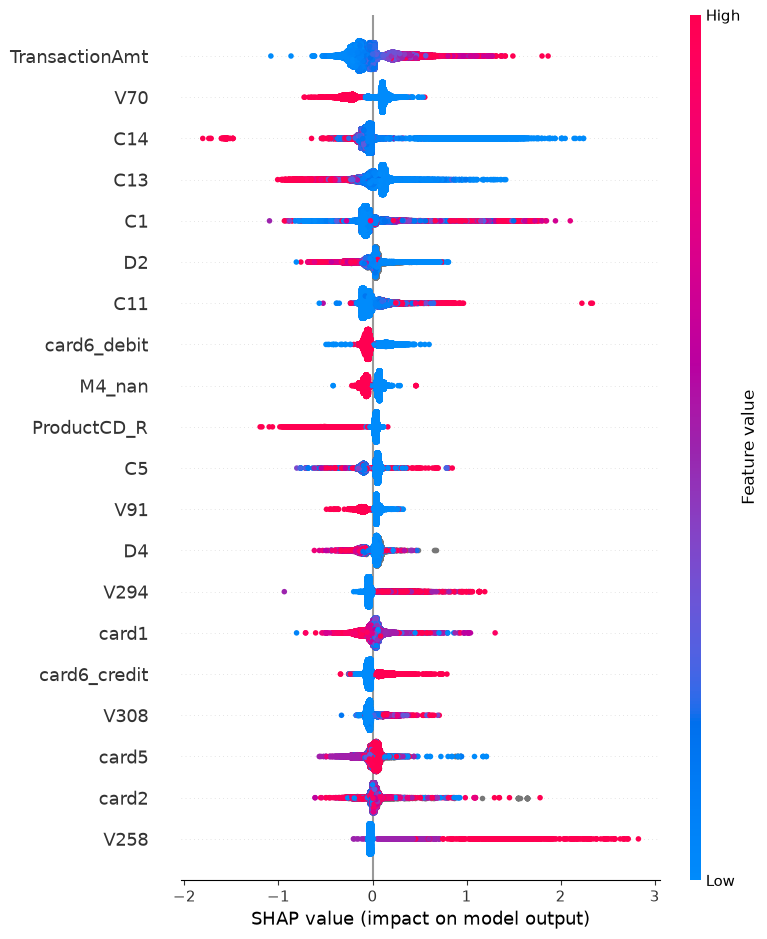

In [72]:
shap.summary_plot(shap_values_sample, X_sample_para_graficar)

## Análisis del Summary Plot de SHAP

Calculé los valores SHAP del modelo LightGBM (configuración default) usando TreeExplainer sobre train_final, y grafiqué una muestra de 5,000 transacciones para que el gráfico fuera manejable sin perder validez, ya que el cálculo pesado se hizo sobre el modelo completo. En el summary plot, la posición horizontal indica si una variable empuja la predicción hacia más fraude (derecha) o menos fraude (izquierda), y el color indica si el valor de esa variable es alto (rojo) o bajo (azul) en cada transacción. Lo más interesante es que TransactionAmt resultó ser la variable más importante del modelo, a pesar de que en el EDA había concluido que era una señal débil de forma aislada — esto tiene sentido porque probablemente se vuelve informativa al combinarse con otras variables, que es justo la idea detrás de la feature amt_relative_to_card que creé en Feature Engineering. También confirmé varios hallazgos que ya tenía del EDA: card6_debit empuja hacia menos fraude y card6_credit hacia más fraude, coincidiendo con las tasas de 2.4% vs 6.7% que ya había calculado, y ProductCD_R también aparece como relevante, consistente con las diferencias de tasa de fraude por producto. Por último, varias columnas C, D y V que nunca analicé individualmente en el EDA (como C1, C13, D2, V70, V258) resultaron ser importantes para el modelo, lo cual confirma que fue correcto no descartarlas solo por tener correlación de Pearson baja, ya que el modelo de árboles sí pudo aprovechar relaciones no lineales que ese análisis simple no alcanzaba a detectar.

In [73]:
#Ahora para hacer un analisis vamos a agarrar la muestra de 50 mil filas para buscar una transaccion donde el modelo predice con alta confianza que es fraude
#Esto nos sirve para poder ver si el modelo esta prediciendo correctamente y si es asi podemos ver cuales son las variables que mas influyen 

predicciones_muestra = lgbm_default.predict_proba(X_sample_para_graficar)[:, 1]

y_sample = y_train_final.loc[X_sample_para_graficar.index]

casos_fraude_detectado = X_sample_para_graficar[(y_sample == 1) & (predicciones_muestra > 0.7)]

print(f"Casos de fraude real detectados con alta confianza: {len(casos_fraude_detectado)}")
print(casos_fraude_detectado.index[:5].tolist())

Casos de fraude real detectados con alta confianza: 668
[262734, 279700, 81095, 303624, 302975]


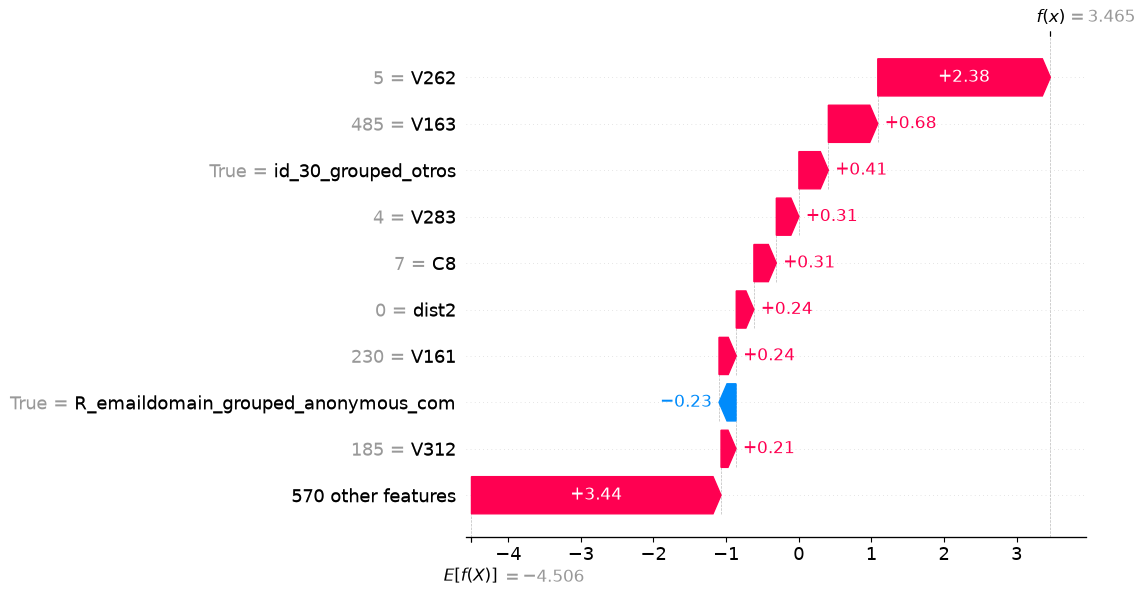

In [74]:
#Ahora vamos a tomar el caso de la fila 262734 para explicar por que el modelo lo predijo como fraude con alta confianza

caso_id = 262734

# Ubicamos la posición de esa fila dentro de tu muestra
posicion = X_sample_para_graficar.index.get_loc(caso_id)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_sample[posicion],
        base_values=explainer.expected_value,
        data=X_sample_para_graficar.iloc[posicion],
        feature_names=X_sample_para_graficar.columns.tolist()
    )
)

## Análisis del Waterfall Plot — Caso individual de fraude detectado

Estas son las principales variables que empujaron a esta transacción a ser marcada como fraude, siendo la más importante V262 con un valor de 5, que por sí sola impulsó la predicción +2.38. El valor E[f(X)] = -4.506 es el punto de partida promedio del modelo en su escala interna (log-odds), y está tan sesgado hacia "no fraude" precisamente porque el 96.5% de las transacciones del dataset no son fraude — por eso se necesita acumular bastante evidencia para mover la predicción hasta un valor tan alto como el que se ve aquí. Sumando el efecto de las variables individuales mostradas más el de las otras 570 variables restantes (que en conjunto aportaron +3.44), se llega a la predicción final f(x) = 3.465, un valor muy alto que indica que el modelo está prácticamente seguro de que esta transacción es fraude. También es interesante que una de las variables con más peso jaló en la dirección contraria: R_emaildomain_grouped_anonymous_com en True restó -0.23 a la predicción, es decir, en este caso específico el modelo asoció tener un dominio de correo "anonymous.com" en el destinatario con menor probabilidad de fraude — aunque esto es una lectura válida para esta transacción puntual, no necesariamente una regla general de negocio sin revisar si el patrón se repite en más casos.

In [75]:
#Ahora repetimos el proceso para ver un caso de un falso positivo (donde el modelo predice con alta confianza que es fraude pero en realidad no lo es)

casos_falso_positivo = X_sample_para_graficar[(y_sample == 0) & (predicciones_muestra > 0.7)]

print(f"Falsos positivos con alta confianza: {len(casos_falso_positivo)}")
print(casos_falso_positivo.index[:5].tolist())

Falsos positivos con alta confianza: 20
[52573, 103708, 370491, 44266, 268752]


Se puede ver como en el mismo set de datos cuando el modelo marco con alta confianza (>0.7) de fraude teniamos 668 casos, mientras que falsos negativos de alta confianza solo tenemos 20

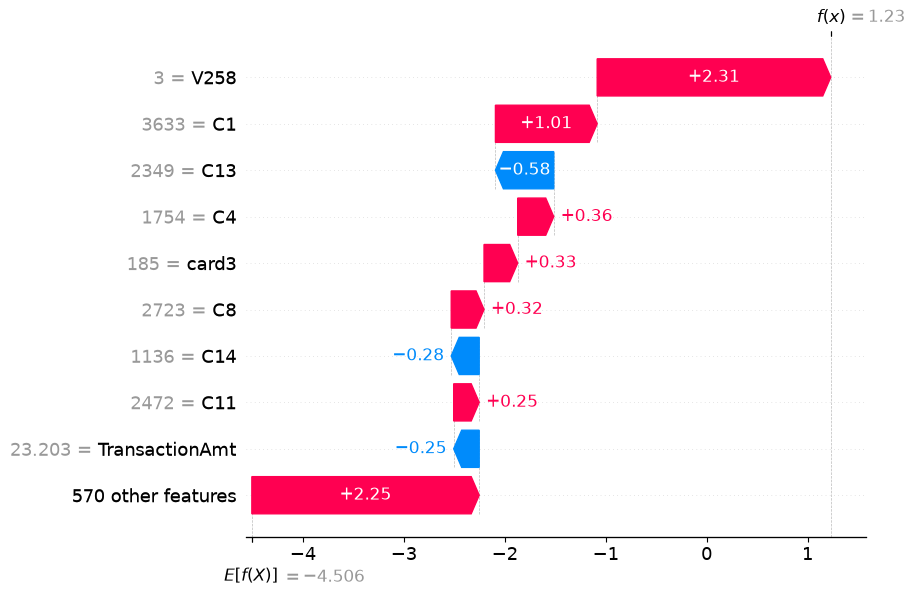

In [76]:
caso_id_fp = 52573
posicion_fp = X_sample_para_graficar.index.get_loc(caso_id_fp)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_sample[posicion_fp],
        base_values=explainer.expected_value,
        data=X_sample_para_graficar.iloc[posicion_fp],
        feature_names=X_sample_para_graficar.columns.tolist()
    )
)

## Análisis del Waterfall Plot — Caso de falso positivo

En este caso, el modelo predijo fraude (f(x) = 1.23) para una transacción que en realidad era legítima, pero lo primero que noto es que esta confianza final es mucho menor que la del caso de fraude verdadero que ya analicé (3.465) — el modelo "dudó" bastante más aquí, aunque terminó del lado equivocado. La variable dominante fue V258 (valor 3), aportando +2.31, del mismo tipo de columna anónima de Vesta que ya había visto como influyente en el caso anterior (V262), lo que sugiere que estas columnas V específicas son un motor fuerte de las predicciones en general. Lo más interesante es que varias columnas C (C1, C4, C8, C11, C13, C14) aparecen aquí, pero no todas apuntan en la misma dirección: C1 (+1.01) y C4 (+0.36) empujan hacia fraude, mientras que C13 (-0.58) y C14 (-0.28) empujan hacia no fraude — es decir, hubo señales contradictorias entre las propias columnas C, y la suma neta terminó inclinándose incorrectamente hacia fraude. También noto que TransactionAmt, con un valor bajo (23.2), aportó -0.25, empujando ligeramente hacia no fraude, coherente con la idea de que montos bajos tienden a ser más normales, pero no fue suficiente para contrarrestar el resto de la evidencia. Comparando ambos casos, veo un patrón: cuando la evidencia es consistente y apunta mayormente en una sola dirección, el modelo acierta con alta confianza; cuando hay señales mixtas entre variables, la confianza final es más baja y el riesgo de error aumenta — esto respalda la idea de que ajustar el umbral de decisión podría ayudar a filtrar varios de estos falsos positivos de baja confianza, sin perder tantos verdaderos positivos, que suelen tener confianza mucho más alta.

In [77]:
#Ahora vamos a hacer un modelo no supervisado con isolation forest, por lo que primero vamos a buscar las columnas numericas con mas importancia para poder hacer el analisis de outliers 


importancia_shap = pd.DataFrame({
    'feature': X_sample_para_graficar.columns,
    'importancia_media_abs': np.abs(shap_values_sample).mean(axis=0)
}).sort_values('importancia_media_abs', ascending=False)

# Filtramos solo columnas numéricas continuas (excluyendo dummies binarias 0/1)
stats_min_max = X_train_final[importancia_shap['feature']].agg(['min', 'max']).T
cols_no_binarias = stats_min_max[~((stats_min_max['min'] == 0) & (stats_min_max['max'] == 1))].index

importancia_shap_numericas = importancia_shap[importancia_shap['feature'].isin(cols_no_binarias)]

print(importancia_shap_numericas.head(30))

            feature  importancia_media_abs
0    TransactionAmt               0.177965
107             V70               0.165550
22              C14               0.135788
21              C13               0.116611
9                C1               0.106444
24               D2               0.097182
19              C11               0.089201
13               C5               0.073902
128             V91               0.073822
26               D4               0.071878
331            V294               0.066637
1             card1               0.065197
345            V308               0.058964
4             card5               0.058565
2             card2               0.050934
295            V258               0.050468
10               C2               0.050167
3             card3               0.050089
25               D3               0.048641
202            V165               0.044614
37              D15               0.042812
27               D5               0.038588
5          

In [78]:
#Verificamos que esta columna no sea un identificador unico para poder usarla en el modelo de isolation forest
print(X_train_final['V308'].nunique())

print(X_train_final['V308'].describe())
print(X_train_final['V308'].value_counts().head(10))

15379
count    377945.000000
mean        102.530753
std         621.906107
min           0.000000
25%           0.000000
50%           0.000000
75%          30.935600
max      101640.000000
Name: V308, dtype: float64
V308
0.000000      274786
117.000000      3305
59.000000       3273
57.950001       2244
100.000000      1931
107.949997      1931
49.000000       1630
50.000000       1459
226.000000      1405
39.000000       1188
Name: count, dtype: int64


In [79]:
#Verificamos que tenemos que descartar las columnas car 1 y adrr1 ya que estas son columnas de identificacion y no tienen sentido para el modelo de isolation forest


print(X_train_final['card1'].nunique())
print(X_train_final['card1'].describe())

print(X_train_final['addr1'].nunique())
print(X_train_final['addr1'].describe())

11945
count    377945.000000
mean       9864.466060
std        4904.002037
min        1000.000000
25%        6019.000000
50%        9633.000000
75%       14128.000000
max       18396.000000
Name: card1, dtype: float64
311
count    335941.000000
mean        290.625017
std         101.975047
min         100.000000
25%         204.000000
50%         299.000000
75%         330.000000
max         540.000000
Name: addr1, dtype: float64


In [80]:
features_anomalias_final = importancia_shap_numericas.head(13)['feature'].tolist()
features_anomalias_final = [f for f in features_anomalias_final if f != 'card1']

print(features_anomalias_final)

X_anomalias = X_train_final[features_anomalias_final]

from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.035, random_state=42, n_jobs=1)
iso_forest.fit(X_anomalias)

anomaly_pred = iso_forest.predict(X_anomalias)

print(pd.Series(anomaly_pred).value_counts())

['TransactionAmt', 'V70', 'C14', 'C13', 'C1', 'D2', 'C11', 'C5', 'V91', 'D4', 'V294', 'V308']
 1    364716
-1     13229
Name: count, dtype: int64


In [81]:
for col in features_anomalias_final:
    n_unique = X_train_final[col].nunique()
    total = len(X_train_final)
    print(f"{col}: {n_unique} valores únicos ({n_unique/total:.2%} del total)")

TransactionAmt: 14925 valores únicos (3.95% del total)
V70: 7 valores únicos (0.00% del total)
C14: 1079 valores únicos (0.29% del total)
C13: 1581 valores únicos (0.42% del total)
C1: 1541 valores únicos (0.41% del total)
D2: 637 valores únicos (0.17% del total)
C11: 1389 valores únicos (0.37% del total)
C5: 303 valores únicos (0.08% del total)
V91: 7 valores únicos (0.00% del total)
D4: 724 valores únicos (0.19% del total)
V294: 237 valores únicos (0.06% del total)
V308: 15379 valores únicos (4.07% del total)


In [82]:
#Ahora con nuestro set de datos de anomalias vamos a hacer un analisis de las anomalias que detecto el modelo de isolation forest 

X_anomalias = X_train_final[features_anomalias_final]

from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.035, random_state=42, n_jobs=1)
iso_forest.fit(X_anomalias)

anomaly_pred = iso_forest.predict(X_anomalias)

print(pd.Series(anomaly_pred).value_counts())

 1    364716
-1     13229
Name: count, dtype: int64


In [83]:
#Ahora vamos a hacer una comparacion de las predicciones del modelo de isolation forest con el target isFraud

comparacion = pd.DataFrame({
    'anomaly_pred': anomaly_pred,
    'isFraud': y_train_final.values
})

tabla_comparacion = pd.crosstab(comparacion['anomaly_pred'], comparacion['isFraud'])
print(tabla_comparacion)

# Tasa de fraude dentro de las marcadas como anómalas vs normales
tasa_fraude_anomalo = comparacion[comparacion['anomaly_pred'] == -1]['isFraud'].mean()
tasa_fraude_normal = comparacion[comparacion['anomaly_pred'] == 1]['isFraud'].mean()

print(f"\nTasa de fraude en transacciones ANÓMALAS: {tasa_fraude_anomalo:.2%}")
print(f"Tasa de fraude en transacciones NORMALES: {tasa_fraude_normal:.2%}")

isFraud            0      1
anomaly_pred               
-1             12866    363
 1            352184  12532

Tasa de fraude en transacciones ANÓMALAS: 2.74%
Tasa de fraude en transacciones NORMALES: 3.44%


In [84]:
iso_forest_v2 = IsolationForest(
    n_estimators=200,
    max_samples=0.5,  # usa 50% de las filas en cada árbol, en vez del default pequeño
    contamination=0.035,
    random_state=42,
    n_jobs=1
)
iso_forest_v2.fit(X_anomalias)

anomaly_pred_v2 = iso_forest_v2.predict(X_anomalias)

comparacion_v2 = pd.DataFrame({'anomaly_pred': anomaly_pred_v2, 'isFraud': y_train_final.values})

tasa_fraude_anomalo_v2 = comparacion_v2[comparacion_v2['anomaly_pred'] == -1]['isFraud'].mean()
tasa_fraude_normal_v2 = comparacion_v2[comparacion_v2['anomaly_pred'] == 1]['isFraud'].mean()

print(f"Tasa de fraude en ANÓMALAS (v2): {tasa_fraude_anomalo_v2:.2%}")
print(f"Tasa de fraude en NORMALES (v2): {tasa_fraude_normal_v2:.2%}")

Tasa de fraude en ANÓMALAS (v2): 3.70%
Tasa de fraude en NORMALES (v2): 3.40%


In [85]:
#Ajustamos el valor de ocntamination a el 0.01 que es el 1% de las transacciones mas raras y vemos si mejora la tasa de fraude en las anomalias detectadas
iso_forest_v3 = IsolationForest(
    n_estimators=200,
    max_samples=0.5,
    contamination=0.01,
    random_state=42,
    n_jobs=1
)
iso_forest_v3.fit(X_anomalias)

anomaly_pred_v3 = iso_forest_v3.predict(X_anomalias)

comparacion_v3 = pd.DataFrame({'anomaly_pred': anomaly_pred_v3, 'isFraud': y_train_final.values})
tasa_fraude_anomalo_v3 = comparacion_v3[comparacion_v3['anomaly_pred'] == -1]['isFraud'].mean()
tasa_fraude_normal_v3 = comparacion_v3[comparacion_v3['anomaly_pred'] == 1]['isFraud'].mean()

print(f"Tasa de fraude en ANÓMALAS (top 1% más raras): {tasa_fraude_anomalo_v3:.2%}")
print(f"Tasa de fraude en NORMALES: {tasa_fraude_normal_v3:.2%}")

Tasa de fraude en ANÓMALAS (top 1% más raras): 5.93%
Tasa de fraude en NORMALES: 3.39%


In [86]:
def calcular_costo_total(y_true, y_pred, montos, costo_fp=3.47, multiplicador_fn=4.41):
    """
    Calcula el costo total de negocio de las predicciones del modelo,
    usando estimados basados en datos reales de la industria:
    - Falso Positivo: $3.47 USD (Signifyd, costo promedio de revisión manual)
    - Falso Negativo: monto de la transacción x 4.41 (multiplicador
      'True Cost of Fraud' de LexisNexis, que captura costo total del
      fraude más allá del monto directo)
    """
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    montos = pd.Series(montos).reset_index(drop=True)

    falsos_positivos = (y_true == 0) & (y_pred == 1)
    falsos_negativos = (y_true == 1) & (y_pred == 0)

    costo_fp_total = falsos_positivos.sum() * costo_fp
    costo_fn_total = (montos[falsos_negativos] * multiplicador_fn).sum()

    costo_total = costo_fp_total + costo_fn_total

    return {
        'costo_total': costo_total,
        'costo_falsos_positivos': costo_fp_total,
        'costo_falsos_negativos': costo_fn_total,
        'num_falsos_positivos': int(falsos_positivos.sum()),
        'num_falsos_negativos': int(falsos_negativos.sum())
    }

## Cómo calculamos los costos de Falso Positivo y Falso Negativo
 
Desde la Etapa 1 habíamos identificado que un falso negativo (fraude no detectado) cuesta más que un falso positivo (transacción legítima bloqueada), pero nunca habíamos puesto números reales a esa diferencia — solo lo usábamos como criterio cualitativo. En la Etapa 14 decidí buscar cifras reales de la industria en vez de inventar estimaciones, para que la función de costo fuera defendible.
 
**Costo de Falso Positivo: $3.47 USD por transacción.** Este número viene de datos publicados por Signifyd, una empresa de prevención de fraude, que reporta que una revisión manual de fraude cuesta en promedio $3.47 USD. Preferí este dato sobre estimar manualmente "minutos × tarifa por hora de un analista", porque es una medición directa de la industria en vez de una suposición mía sin respaldo.
 
**Costo de Falso Negativo: monto de la transacción × 4.41.** Este multiplicador viene del estudio *True Cost of Fraud* de LexisNexis, que encontró que cada dólar perdido directamente por fraude le cuesta en realidad $4.41 a las instituciones financieras de Norteamérica, una vez que se suman los costos indirectos: multas, comisiones, y el esfuerzo operativo de investigar la transacción fraudulenta. Usar este multiplicador en vez de solo el monto directo captura mejor el costo real del fraude, no solo la pérdida inmediata.
 
Con estos dos costos, construí una función que calcula el costo total de negocio de las predicciones del modelo para un umbral de decisión dado, sumando (número de falsos positivos × $3.47) + (suma de los montos de los falsos negativos × 4.41). Usando esta función sobre el conjunto de test, encontré que el umbral que minimiza el costo total real (0.0058) es mucho más bajo que el umbral por defecto (0.5) o el que había optimizado por F1 en la Etapa 4 (0.124) — confirmando con números reales la intuición de la Etapa 1: como un fraude no detectado sale mucho más caro que una falsa alarma, el modelo debe ser más "alarmista" de lo que sugeriría una métrica puramente estadística.
 
**Fuentes:**
- Signifyd — costo promedio de revisión manual de fraude: https://www.signifyd.com/blog/manual-fraud-review/
- LexisNexis — *True Cost of Fraud* Study (multiplicador de costo de fraude): https://risk.lexisnexis.com/insights-resources/research/us-ca-true-cost-of-fraud-study
 

In [90]:
import os
print(os.getcwd())

/home/sgc081372/proyectos/fraudshield-ai/notebooks


In [92]:
import joblib
modelo = joblib.load('../models/modelo_final.pkl')
feature_cols = joblib.load('../models/feature_cols.pkl')

In [93]:
test_encoded = pd.read_parquet('../data/processed/test_encoded_final.parquet')
X_test_final_costo = test_encoded[feature_cols].copy()
X_test_final_costo.columns = [c.replace(':', '_').replace('/', '_').replace('.', '_').replace(' ', '_') for c in X_test_final_costo.columns]

probabilidades = modelo.predict_proba(X_test_final_costo)[:, 1]

for umbral in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    predicciones_umbral = (probabilidades >= umbral).astype(int)
    resultado = calcular_costo_total(
        test_encoded['isFraud'].values,
        predicciones_umbral,
        test_encoded['TransactionAmt'].values
    )
    print(f"Umbral {umbral}: Costo total = ${resultado['costo_total']:,.2f} "
          f"(FP: {resultado['num_falsos_positivos']}, FN: {resultado['num_falsos_negativos']})")

Umbral 0.05: Costo total = $776,081.08 (FP: 9431, FN: 1107)
Umbral 0.1: Costo total = $1,172,022.02 (FP: 4062, FN: 1626)
Umbral 0.15: Costo total = $1,440,365.52 (FP: 2502, FN: 1943)
Umbral 0.2: Costo total = $1,601,078.29 (FP: 1775, FN: 2142)
Umbral 0.3: Costo total = $1,790,362.80 (FP: 972, FN: 2369)
Umbral 0.5: Costo total = $2,033,120.94 (FP: 409, FN: 2687)


In [95]:
thresholds_a_probar_v2 = np.arange(0.0001, 0.02, 0.0001)

resultados_costo_v2 = []
for umbral in thresholds_a_probar_v2:
    predicciones_umbral = (probabilidades >= umbral).astype(int)
    resultado = calcular_costo_total(
        test_encoded['isFraud'].values,
        predicciones_umbral,
        test_encoded['TransactionAmt'].values
    )
    resultados_costo_v2.append({'umbral': umbral, 'costo_total': resultado['costo_total']})

costos_df_v2 = pd.DataFrame(resultados_costo_v2)
mejor_fila_v2 = costos_df_v2.loc[costos_df_v2['costo_total'].idxmin()]

print(f"Umbral óptimo de negocio (rango expandido): {mejor_fila_v2['umbral']:.5f}")
print(f"Costo total mínimo: ${mejor_fila_v2['costo_total']:,.2f}")

# Verifiquemos también qué pasa en el extremo, con umbral = 0 (marcar TODO como fraude)
pred_todo_fraude = np.ones(len(test_encoded))
resultado_extremo = calcular_costo_total(test_encoded['isFraud'].values, pred_todo_fraude, test_encoded['TransactionAmt'].values)
print(f"\nUmbral 0 (marcar TODO como sospechoso): Costo total = ${resultado_extremo['costo_total']:,.2f}")

Umbral óptimo de negocio (rango expandido): 0.00580
Costo total mínimo: $313,816.70

Umbral 0 (marcar TODO como sospechoso): Costo total = $395,732.68


## Nota sobre el umbral de decisión usado en la API y el dashboard

En la Etapa 14 encontré, usando la función de costo real (FP=$3.47, FN=monto×4.41), que el umbral que minimiza el costo total de negocio es 0.0058 — mucho más bajo que el 0.5 que uso actualmente en `api.py` y `app.py` para decidir entre "fraude" y "legítima".

Decidí **no cambiar el umbral hardcodeado en el código** por dos razones. Primero, un sistema real nunca debería tener el umbral fijo directamente en el código de la aplicación — debería vivir como un parámetro configurable (una variable de entorno, un archivo de configuración, o un valor cargado dinámicamente), precisamente porque los costos de negocio (el costo de una revisión manual, el multiplicador de costo de fraude) pueden cambiar con el tiempo, y el sistema debería poder ajustarse sin tener que modificar y redesplegar el código. Segundo, el umbral 0.0058 fue calculado con estimaciones de costo tomadas de estudios generales de la industria, no con datos de costos reales de mi propio negocio, así que tratarlo como un valor definitivo sería prematuro.

Por eso dejé 0.5 como valor por defecto en el código (más simple de entender para cualquiera que revise el proyecto), y documento aquí que, si este sistema fuera a producción real, el umbral debería configurarse externamente y ajustarse al valor óptimo de negocio calculado en la Etapa 14 (o recalcularse con costos reales específicos de la empresa), no dejarse en el 0.5 arbitrario.